# Implementation of Krotov's method for quantum control

```2026/04/18```

1. Review theory for Krotov and write it here;
2. Follow pseudocode;
3. Compare to ```krotov``` package.


Let's go over the formulation already in the lingo of the case we're studying here.

### Basic Formulation

The Schrödinger equation:

$$
\begin{equation}
    \frac{\partial}{\partial t} \ket{\Psi(t)} = -\frac{i}{\hbar}\hat H(t) \ket{\Psi(t)}
\tag{1}
\end{equation}
$$

The total hamiltonian is composed of the system's natural hamiltonian and a coupling term to the external field $\epsilon(t)$:

$$
\begin{align}
\tag{2}
    \hat H(\hat R, \hat P, t) &= \hat H_0(\hat R, \hat P) + \epsilon(t) \hat H_I(\hat R, t) \\
    \hat H_0(\hat R, \hat P) &= \frac{\hat P^2}{2} + V(\hat R) \nonumber \\
    \hat H_I(\hat R, t) &= \epsilon(t) \hat R \nonumber

\end{align}
$$

### Optimization Functional

The optimization functional is given by (in the case of only a single control $\epsilon(t)$, and no state-dependent running cost, $g_b = 0$):

$$
\begin{equation}
    J[\{\ket{\phi_k^{(i)}(t)}\}, \epsilon^{(i)}] = J_T[\{\ket{\phi_k^{(i)}(T)}\}] + \int_0^T g_a(\epsilon^{(i)}(t) ) \mathrm d t
\tag{3}
\end{equation}
$$

- Running cost of the controls $g_a$:

$$
\begin{equation}
    g_a(\epsilon^{(i)}(t)) = \frac{\lambda_a}{S(t)} \left( \Delta \epsilon^{(i)}(t) \right)^2,
\tag{4}
\end{equation}
$$
where $\Delta \epsilon^{(i)}(t) \equiv \epsilon^{(i)}(t) - \epsilon^{(i-1)}(t)$.

- Final time functional: $J_T$;

Designed to optimize a set of initial states $\{\ket{\phi_k}\}$ to a set of target states $\{\ket{\phi_k^{tgt}}\}$. Calculates the complex overlap of states:

$$
\begin{equation}
    \tau_k = \braket{\phi_k^{tgt}|\phi_k(T)}
\tag{5}
\end{equation}
$$

Optimize for simultaneous state-to-state transitions, with completely arbitrary phases:

$$
\begin{equation}
    J_{T,ss} = 1 - \frac{1}{N} \sum_{k=1}^N |\tau_k|^2
\tag{6}
\end{equation}
$$

$S(t)$ is a function which governs the update shape for the control. If we set its extremum values (at $t=t_0$ and $t=T$) to 0 then the boundary conditions on $\epsilon^*(t)$ are fixed at 0 (we are forced to do so). This is because the control update $\Delta \epsilon(t)$ is proportional to $S(t)/\lambda_a$, where $\lambda_a$ is the inverse Krotov step. An example is:

$$
\begin{equation}
    S_l(t) =
    \tag{7}
    \begin{cases}
        B(t; t_0 = 0, t_1 = 2t_{\mathrm{on}}) & \text{for } 0 < t < t_{\mathrm{on}} \\
        1 & \text{for } t_{\mathrm{on}} \le t \le T - t_{\mathrm{off}} \\
        B(t; t_0 = T - 2t_{\mathrm{off}}, t_1 = T) & \text{for } T - t_{\mathrm{off}} < t < T
    \end{cases}
\end{equation},
$$
where $B(t; t_0, t_1)$ is the *Blackman shape*:

$$
\begin{equation}
    B(t; t_0, t_1) = \frac{1}{2} \left(
    1 - a - \cos\left(2\pi \frac{t - t_0}{t_1 - t_0}\right)
    + a \cos\left(4\pi \frac{t - t_0}{t_1 - t_0}\right)
    \right), \quad a = 0.16
\tag{8}
\end{equation}
$$

It can be proven, although I will not do so, that the condition for monotonic convergence is:

$$
\begin{equation}
    \frac{\partial g_a}{\partial \epsilon(t)} \Bigg | _{(i)} = 2 \mathrm{Im} \left [ 
    \sum_{k=1}^N \Bigg \langle \chi_k^{(i-1)}(t) \Bigg | \left ( 
    \frac{\partial \hat H}{\partial \epsilon(t)} \Big | _{(i)} \right ) \Bigg | 
    \phi_k^{(i)}(t) \Bigg \rangle \right ].
\tag{9}
\end{equation}
$$

Which yelds the updated control equation, using (4) and (9):

$$
\begin{equation}
    \Delta \epsilon^{(i)}(t) = \frac{S(t)}{\lambda_a} \mathrm{Im} \left [ 
    \sum_{k=1}^N \Bigg \langle \chi_k^{(i-1)}(t) \Bigg | \left ( 
    \frac{\partial \hat H}{\partial \epsilon(t)} \Big | _{(i)} \right ) \Bigg | 
    \phi_k^{(i)}(t) \Bigg \rangle \right ].
\tag{10}
\end{equation}
$$


With the forward propagation of states given by:

$$
\begin{equation}
    \frac{\partial}{\partial t} \ket{\phi_k^{(i)}(t)}
    = -\frac{i}{\hbar} \hat{H}^{(i)} \ket{\phi_k^{(i)}(t)}
\tag{11}
\end{equation}
$$

And the backwards propagation given by:

$$
\begin{equation}
    \frac{\partial}{\partial t} \ket{\chi_k^{(i-1)}(t)}
    = -\frac{i}{\hbar} \hat{H}^{\dagger (i-1)} \ket{\chi_k^{(i-1)}(t)},
\tag{12}
\end{equation}
$$
with the final time condition:

$$
\begin{equation}
    \ket{\chi_k^{(i-1)}(T)}
    = - \left. \frac{\partial J_T}{\partial \langle \phi_k(T) |} \right|_{(i-1)}
\tag{13}
\end{equation}
$$

For the $J_{T,ss}$, this derivative is (for $N = 1$):

$$
\begin{equation}
    \ket{\chi^{(i-1)}(T)} =
    \frac{\partial}{\partial \bra{\phi(T)}}
    \braket{\phi(T) | \phi^{\mathrm{tgt}}}
    \braket{\phi^{\mathrm{tgt}} | \phi(T)}
    \Big | _{(i-1)}
    =
    \braket{\phi^{\mathrm{tgt}} | \phi^{(i-1)}(T)}
    \ket{\phi^{\mathrm{tgt}}}
\tag{14}
\end{equation}
$$

Additionally, $\partial \hat H/\partial \epsilon(t)$ can be calculated in our case and simply yelds $\hat R$.

A general scheme can be summarized for the optimization procedure (considering one objective: $N = 1$):

1. Define the co-state $\ket{\chi^{(i-1)}(T)}$ Through (14), using the state propagated in the last iteration $\ket{\phi^{(i-1)}(T)};
2. Back propagate the co-state using equation 12, record the co-states for each time step; 
3. Using a fixed initial state $\ket{\phi_0} = \ket{\phi(t_0)}$, calculate the pulse opdate for the first time step:

$$
\begin{equation}
    \Delta \epsilon_1^{(i)} \equiv \Delta\epsilon^{(i)}(\tilde t_0) = 
    \frac{S(\tilde t_0)}{\lambda_a} \mathrm{Im} \left [ 
    \Bigg \langle \chi^{(i-1)}(t_0) \Bigg | 
    \frac{\partial \hat H}{\partial \epsilon} \Bigg | 
    \phi(t_0) \Bigg \rangle \right ],
\tag{15}
\end{equation}
$$
defining $\tilde t_0 \equiv t_0 + \mathrm{d}t/2$.

4. Calculate $\epsilon_1^{(i)}$ as $\epsilon_1^{(i-1)} + \Delta \epsilon_1^{(i)}$ and use it to propagate $\ket{\phi(t_0)}$ to $\ket{\phi^{(i)}(t_0 + \mathrm{d}t)}$, of course, using (11). From this point on, repeat with this general update scheme ultil the state $\ket{\phi^{(i)}(T)}$:

$$
\begin{equation}
    \Delta \epsilon_{n+1}^{(i)} \equiv \Delta\epsilon^{(i)}(\tilde t_n) = 
    \frac{S(\tilde t_n)}{\lambda_a} \mathrm{Im} \left [ 
    \Bigg \langle \chi^{(i-1)}(t_n) \Bigg | 
    \frac{\partial \hat H}{\partial \epsilon} \Bigg | 
    \phi(t_n) \Bigg \rangle \right ], \quad \tilde t_n \equiv t_n + \mathrm{d}t/2
\tag{16}
\end{equation}
$$

5. Calculate $J_T^{(i)}$ and $\Delta J_T^{(i)}$ and repeat until they lie below a threshold.


Now, let's start the proccess of implementation for the Morse-soft-Coulomb (MsC) potential.

Firstly, we need to define the operators:

$$
\hat H_0 = \frac{\hat P^2}{2} + V_{MsC}(\hat R; \alpha)
$$
$$
\hat H_I = \epsilon(t) \hat R
$$

In matrix form, using the **Fourier Grid Hamiltonian** method, we can represent $\hat H_0$ in matrix form:

In [1]:
from emerald.quantum.msc_unperturbed import MsC_hamiltonian, MsC_eigstates
from emerald.potentials.msc_potential import MsC_return_points, MsC_potential

import numpy as np

# We will start with a global α parameter of 1 and energy of -0.5
alpha = 1
E0 = -0.5

# We define a position grid to calculate the Hamiltonian.

rm, rM = MsC_return_points(alpha, E0)
print(f"Return points: rm = {rm:.3f}, rM = {rM:.3f}")

# The position grid must acomodate the region where the wavefunction is non-negligible, 
# so we will use a grid that goes from below rm to higher than rM.

r_min = -3.5#rm*5
r_max = 1000#rM*20
print(f"Position grid: r_min = {r_min:.3f}, r_max = {r_max:.3f}")

# Let's check the potential at the boundaries of the grid.
V_r_min = MsC_potential(alpha, r_min)
V_r_max = MsC_potential(alpha, r_max)
print(f"Potential at r_min: V({r_min:.3f}) = {V_r_min:.3f}")
print(f"Potential at r_max: V({r_max:.3f}) = {V_r_max:.3f}")

# Defining the position grid.
N_points = 5000
r_grid = np.linspace(r_min, r_max, N_points)
print(f"dr = {r_grid[1] - r_grid[0]:.3f}")

# Now we can calculate the Hamiltonian matrix on this grid.
H, r_grid = MsC_hamiltonian(alpha, r_grid)

print(f"Hamiltonian matrix shape: {H.shape}")

# Calculate the eigenstates of the Hamiltonian
# truncating the spectrum to the lowest 500 states

base_size = 500
energies, eigstates = MsC_eigstates(H, r_grid, base_size)

print(f"Calculated {len(energies)} eigenstates.")
print(f"Lowest energy eigenvalues: {energies[0]:.3f}, {energies[1]:.3f}, {energies[2]:.3f}")
print(f"Number of bound states (E < 0): {np.sum(energies < 0)}")

Return points: rm = -0.756, rM = 1.732
Position grid: r_min = -3.500, r_max = 1000.000
Potential at r_min: V(-3.500) = 117.379
Potential at r_max: V(1000.000) = -0.001
dr = 0.201
Hamiltonian matrix shape: (5001, 5001)
Calculated 500 eigenstates.
Lowest energy eigenvalues: -0.556, -0.159, -0.067
Number of bound states (E < 0): 28


Now let's calculate the interaction matrix. The operator $\hat R$ can be represented in matrix form in the energy representation:
$$
    \Xi_{nm} = \braket{\varphi_n|\hat R|\varphi_m},
$$
where $\{\ket{\varphi_n}\}$ is the basis of energy (eigenvector of $H_0$)

In [2]:
from emerald.quantum.coupling_utils import interaction_matrix

Xi_vecs, Xi_vals, Xi_conjT = interaction_matrix(r_grid, eigstates)

print(f"Interaction matrix shape: {Xi_vecs.shape}")
print(f"Lowest interaction eigenvalues: {Xi_vals[0]:.3f}, {Xi_vals[1]:.3f}, {Xi_vals[2]:.3f}")

Interaction matrix shape: (500, 500)
Lowest interaction eigenvalues: -0.126, 1.396, 3.142


Now it is convenient to define the single step evolution:

In [3]:
# Single step evolution functions using the split-operator method
# U(δ) = e^-iH₀δ/2 · V · e^-iεΞδ · V† · e^-iH₀δ/2
# U†(δ) = e^iH₀δ/2 · V · e^iεΞδ · V† · e^iH₀δ/2
#
# Optimizations:
#   - Precompute exp_H0 once (outside the loop)
#   - Use Xi_conjT (conjugate transpose) instead of np.linalg.inv
#   - JIT-compile with numba

T = 100.0  # Total duration
delta_t = 0.05  # Time step
time_grid = np.arange(0, T + delta_t, delta_t)
N_T = len(time_grid)
print(f"Time grid: {N_T} points, dt = {delta_t:.3f}")

from numba import njit

# Precompute the free-evolution phase factors (same for all steps)
exp_H0_fwd = np.exp(-1j * energies * delta_t / 2)
exp_H0_bwd = np.exp( 1j * energies * delta_t / 2)


def single_step_evolution(initial_state, external_field_val, exp_H0, Xi_vals, Xi_vecs, Xi_conjT, delta_t):
    tmp = exp_H0 * initial_state
    tmp = Xi_conjT @ tmp
    tmp = np.exp(-1j * external_field_val * Xi_vals * delta_t) * tmp
    tmp = Xi_vecs @ tmp
    return exp_H0 * tmp



def single_step_inverse_evolution(initial_state, external_field_val, exp_H0, Xi_vals, Xi_vecs, Xi_conjT, delta_t):
    tmp = exp_H0 * initial_state
    tmp = Xi_conjT @ tmp
    tmp = np.exp( 1j * external_field_val * Xi_vals * delta_t) * tmp
    tmp = Xi_vecs @ tmp
    return exp_H0 * tmp

Time grid: 2001 points, dt = 0.050


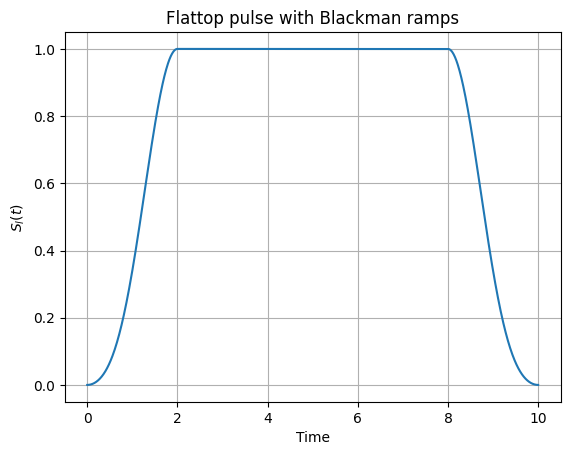

In [4]:
# We also implement the update shape functions:

def blackman_shape(t, t0, t1, a=0.16):
    """
    Implements Eq. (10): Blackman-like shape B(t; t0, t1)

    Parameters
    ----------
    t : float or np.ndarray
        Time value(s)
    t0, t1 : float
        Interval boundaries
    a : float
        Blackman parameter (default 0.16)

    Returns
    -------
    float or np.ndarray
    """
    t = np.asarray(t)

    x = (t - t0) / (t1 - t0)

    return 0.5 * (
        1 - a
        - np.cos(2 * np.pi * x)
        + a * np.cos(4 * np.pi * x)
    )


def S_l(t, T, t_on, t_off):
    """
    Implements Eq. (9): flattop pulse with Blackman ramps

    Parameters
    ----------
    t : float or np.ndarray
    T : float
        Total duration
    t_on : float
        Rise time
    t_off : float
        Fall time

    Returns
    -------
    float or np.ndarray
    """
    t = np.asarray(t)
    result = np.zeros_like(t, dtype=float)

    # Region 1: rising edge
    mask1 = (t > 0) & (t < t_on)
    result[mask1] = blackman_shape(t[mask1], 0, 2 * t_on)

    # Region 2: flat top
    mask2 = (t >= t_on) & (t <= T - t_off)
    result[mask2] = 1.0

    # Region 3: falling edge
    mask3 = (t > T - t_off) & (t < T)
    result[mask3] = blackman_shape(t[mask3], T - 2 * t_off, T)

    return result

import matplotlib.pyplot as plt
# Example usage of the shape function
T = 10.0  # Total duration
t_on = 2.0  # Rise time
t_off = 2.0  # Fall time
t_values = np.linspace(0, T, 1000)
shape_values = S_l(t_values, T, t_on, t_off)
plt.plot(t_values, shape_values)
plt.title("Flattop pulse with Blackman ramps")
plt.xlabel("Time")
plt.ylabel("$S_l(t)$")
plt.grid()
plt.show()

We're almost ready to start experimenting with optimization. It remains to define the optimization functional $J_T$:

In [5]:
def final_time_target_functional(psi_T, psi_target):
    """
    Implements the final-time target functional J_T = 1 - |<ψ(T)|ψ_target>|^2

    Parameters
    ----------
    psi_T : np.ndarray
        Final state at time T
    psi_target : np.ndarray
        Target state

    Returns
    -------
    float
        Value of the final-time target functional
    """
    overlap = np.vdot(psi_T, psi_target)  # <ψ(T)|ψ_target>
    return 1 - np.abs(overlap)**2

And it is also useful to define the final time condition for the co-states

In [6]:
def co_state_final_condition(psi_T, psi_target):
    """
    Implements the final condition for the co-state: χ(T) = -∂J_T/∂<ψ(T)> = <ψ(T)|ψ_target> ψ_target

    Parameters
    ----------
    psi_T : np.ndarray
        Final state at time T
    psi_target : np.ndarray
        Target state

    Returns
    -------
    np.ndarray
        Final condition for the co-state χ(T)
    """
    overlap = np.vdot(psi_T, psi_target)  # <ψ(T)|ψ_target>
    return overlap * psi_target  # χ(T) = <ψ(T)|ψ_target> ψ_target

Also, we will need to perform a an operation of the form $\braket{\chi|\hat R|\phi}$, so, let's define a function to do so:

In [7]:
def R_braket(psi, chi, Xi_vecs, Xi_vals, Xi_conjT):
    """
    Implements the R-braket: <χ(t)|Ξ|ψ(t)> in the energy eigenbasis of the 
    natural Hamiltonian, using the interaction matrix Ξ

    Parameters
    ----------
    psi : np.ndarray
        State at time t
    chi : np.ndarray
        Co-state at time t
    Xi_vecs : np.ndarray
        Eigenvectors of the interaction matrix Ξ
    Xi_vals : np.ndarray
        Eigenvalues of the interaction matrix Ξ
    Xi_conjT : np.ndarray
        Conjugate transpose of Xi_vecs (= inverse for Hermitian Ξ)

    Returns
    -------
    float
        Value of the R-braket
    """
    # Ξ|ψ(t)> = V D V† |ψ(t)>
    Xi_psi = Xi_vecs @ (Xi_vals * (Xi_conjT @ psi))

    # <χ(t)|Ξ|ψ(t)>
    braket = np.vdot(chi, Xi_psi)

    return braket

Let's just start already!

In [8]:
# Optimization loop parameters
max_iterations = 300
lambda_a = 70  # Control update weight
t_on = 10.0  # Rise time for the shape function
t_off = 10.0  # Fall time for the shape function
shape_values = S_l(time_grid, T, t_on, t_off)  # Precompute shape function values for the time grid

Initial field parameters: FieldParams(amplitude=0.5, frequency=0.3969252296905392, form='cos', envelope='linear', rampup_time=10.0, rampdown_time=10.0, operation_time=10.0)


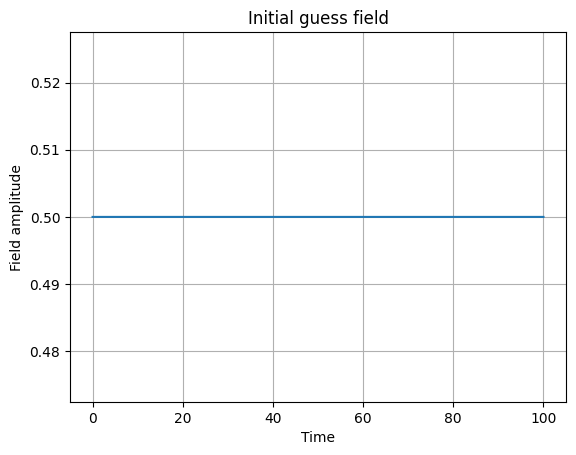

In [9]:
from emerald.utils import FieldParams, external_field_array

# Let's start with optimizing the transition from the ground state to the first excited state.

# Guess field parameters

initial_field_amplitude = 0.5
initial_frequency = np.abs(energies[1] - energies[0])  # Resonant with the transition between the ground and first excited state

field_params = FieldParams(
    amplitude=initial_field_amplitude,
    frequency=initial_frequency,
    envelope='linear',
    operation_time=T,
    rampup_time=t_on,
    rampdown_time=t_off
)
print(f"Initial field parameters: {field_params}")

# initial_guess_field = external_field_array(time_grid, field_params)
initial_guess_field = np.ones_like(time_grid)*initial_field_amplitude
plt.plot(time_grid, initial_guess_field)
plt.title("Initial guess field")
plt.xlabel("Time")
plt.ylabel("Field amplitude")
plt.grid()
plt.show()

In [10]:
# Initial state is the ground state, target state is the first excited state
psi_0 = np.zeros(base_size, dtype=np.complex128)
psi_0[0] = 1.0  # Ground state in energy eigenbasis

psi_target = np.zeros(base_size, dtype=np.complex128)
psi_target[1] = 1.0  # First excited state in energy eigenbasis

phi_history = np.zeros((base_size, N_T), dtype=np.complex128)
chi_history = np.zeros((base_size, N_T), dtype=np.complex128)

# First forward propagation with the initial guess field
curr_guess_field = initial_guess_field.copy()
curr_state = psi_0.copy()
for tau in range(N_T):
    phi_history[:, tau] = curr_state
    curr_state = single_step_evolution(curr_state, curr_guess_field[tau], exp_H0_fwd, Xi_vals, Xi_vecs, Xi_conjT, delta_t)
print("Forward propagation completed.")
print(f"Final state overlap with target: {np.abs(np.vdot(curr_state, psi_target)):.3f}")

chi_history[:, -1] = co_state_final_condition(curr_state, psi_target)
print("Co-state final condition calculated.")   

for tau in reversed(range(N_T - 1)):
    chi_history[:, tau] = single_step_inverse_evolution(chi_history[:, tau + 1], curr_guess_field[tau + 1], exp_H0_bwd, Xi_vals, Xi_vecs, Xi_conjT, delta_t)
print("Backward propagation completed.")
JT_opt_history = np.zeros(max_iterations + 1)
JT_opt_history[0] = final_time_target_functional(curr_state, psi_target)
print(f"Initial functional value: {JT_opt_history[0]:.6f}, Final state overlap with target: {np.abs(np.vdot(curr_state, psi_target)):.3f}")


Forward propagation completed.
Final state overlap with target: 0.155
Co-state final condition calculated.
Backward propagation completed.
Initial functional value: 0.976004, Final state overlap with target: 0.155


In [11]:
def first_order_update(chi, phi, tau, lambda_a, shape_values):
    """
    Implements the first-order update for the control field in Krotov's method:
    Δε(t) = (Sl(t)/λ_a) Im{<χ(t)|Ξ|φ(t)>}

    Parameters
    ----------
    chi : np.ndarray
        Co-state at time t
    phi : np.ndarray
        State at time t
    tau : int
        Time index (used to look up precomputed shape value)
    lambda_a : float
        Control update weight
    shape_values : np.ndarray
        Precomputed S_l(t) values for the entire time grid

    Returns
    -------
    float
        First-order update Δε(t) for the control field at time t
    """
    R_value = R_braket(chi, phi, Xi_vecs, Xi_vals, Xi_conjT)
    delta_epsilon = (shape_values[tau] / lambda_a) * np.imag(R_value)
    return delta_epsilon

In [18]:
i = 0 # Optimization iteration counter

controls = {i: curr_guess_field.copy()}
phi_opt_history = {0: phi_history.copy()}
chi_opt_history = {0: chi_history.copy()}

for i in range(1, max_iterations + 1):
    print(f"Optimization iteration {i}/{max_iterations}")
    phi_history[:, 0] = psi_0

    for n in range(1, N_T):
        # 1. Compute update using φ(tₙ₋₁) and χ(tₙ₋₁)
        delta_eps = first_order_update(
            chi_opt_history[i-1][:, n-1],
            phi_history[:, n-1],
            n - 1,
            lambda_a,
            shape_values
        )
        # 2. Apply update
        curr_guess_field[n] = controls[i-1][n] + delta_eps

        # 3. Propagate with the NEW field
        phi_history[:, n] = single_step_evolution(
            phi_history[:, n-1], curr_guess_field[n], exp_H0_fwd, Xi_vals, Xi_vecs, Xi_conjT, delta_t
        )

    curr_state = phi_history[:, -1]
    controls[i] = curr_guess_field.copy()
    phi_opt_history[i] = phi_history.copy()

    # 4. Back-propagate co-states for the next iteration
    chi_history[:, -1] = co_state_final_condition(curr_state, psi_target)
    for tau in reversed(range(N_T - 1)):
        chi_history[:, tau] = single_step_inverse_evolution(
            chi_history[:, tau + 1], curr_guess_field[tau + 1], exp_H0_bwd, Xi_vals, Xi_vecs, Xi_conjT, delta_t
        )
    chi_opt_history[i] = chi_history.copy()

    functional_value = final_time_target_functional(curr_state, psi_target)
    JT_opt_history[i] = functional_value
    print(f"Functional value: {functional_value:.6f}, Final state overlap with target: {np.abs(np.vdot(curr_state, psi_target)):.3f}")

Optimization iteration 1/300
Functional value: 0.972907, Final state overlap with target: 0.165
Optimization iteration 2/300
Functional value: 0.973208, Final state overlap with target: 0.164
Optimization iteration 3/300
Functional value: 0.972970, Final state overlap with target: 0.164
Optimization iteration 4/300
Functional value: 0.972216, Final state overlap with target: 0.167
Optimization iteration 5/300
Functional value: 0.970957, Final state overlap with target: 0.170
Optimization iteration 6/300
Functional value: 0.969195, Final state overlap with target: 0.176
Optimization iteration 7/300
Functional value: 0.966930, Final state overlap with target: 0.182
Optimization iteration 8/300
Functional value: 0.964161, Final state overlap with target: 0.189
Optimization iteration 9/300
Functional value: 0.960895, Final state overlap with target: 0.198
Optimization iteration 10/300
Functional value: 0.957139, Final state overlap with target: 0.207
Optimization iteration 11/300
Functiona

In [19]:
temp = np.array(JT_opt_history)
opt = np.argmin(temp)
print(f"Optimal iteration: {opt}, Minimum functional value: {temp[opt]:.6f}")

Optimal iteration: 300, Minimum functional value: 0.001316


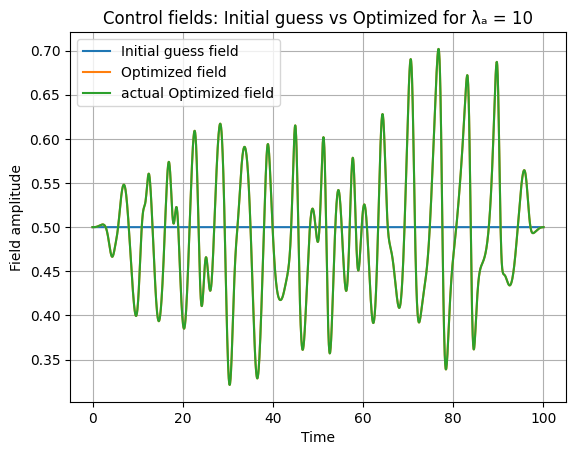

In [20]:
plt.plot(time_grid, controls[0], label='Initial guess field')
plt.plot(time_grid, controls[i-1], label='Optimized field')
plt.plot(time_grid, controls[opt], label='actual Optimized field')
plt.title("Control fields: Initial guess vs Optimized for λₐ = 10")
plt.xlabel("Time")
plt.ylabel("Field amplitude")
plt.legend()
plt.grid()
plt.show()

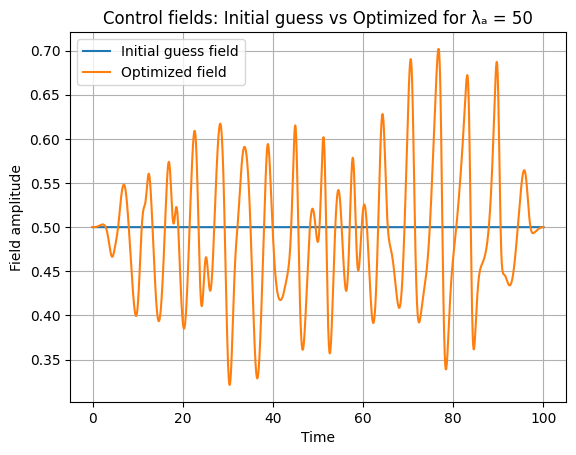

In [21]:
plt.plot(time_grid, controls[0], label='Initial guess field')
plt.plot(time_grid, controls[i], label='Optimized field')
# plt.plot(time_grid, controls[25], label='actual Optimized field')
plt.title("Control fields: Initial guess vs Optimized for λₐ = 50")
plt.xlabel("Time")
plt.ylabel("Field amplitude")
plt.legend()
plt.grid()
plt.show()

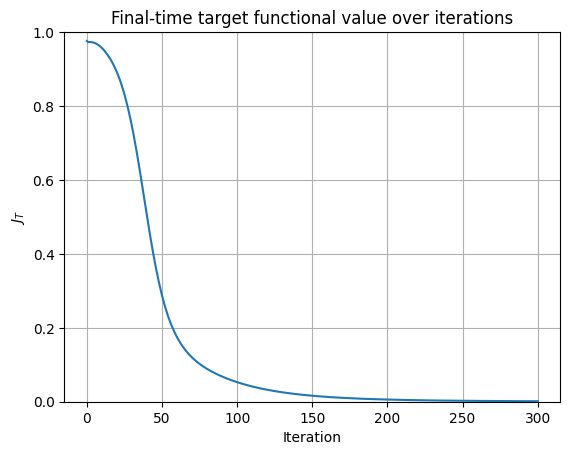

In [22]:
plt.plot(JT_opt_history[:i+1])
plt.title("Final-time target functional value over iterations")
plt.xlabel("Iteration")
plt.ylabel("$J_T$") 
plt.ylim(0, 1)
plt.grid()
plt.show()

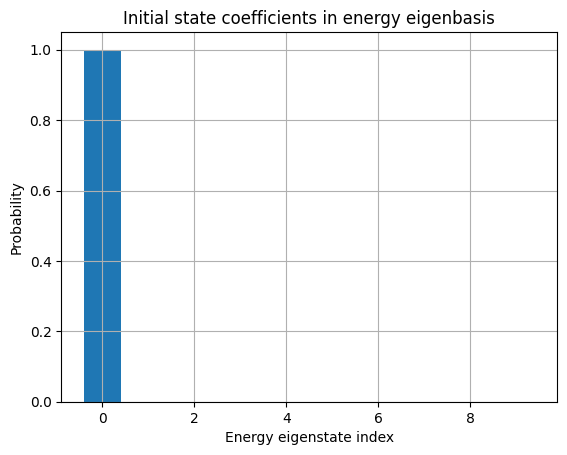

In [27]:
# Plot initial state coefficients in energy eigenbasis
plt.bar(range(base_size)[:10], np.abs(psi_0)[:10])
plt.title("Initial state coefficients in energy eigenbasis")
plt.xlabel("Energy eigenstate index")
plt.ylabel("Probability")
plt.grid()
plt.show()

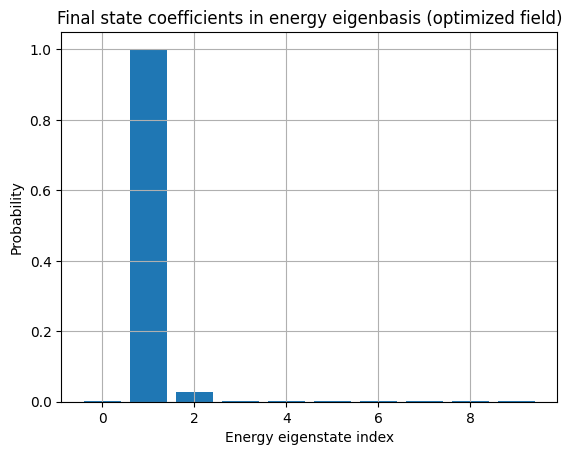

In [29]:
# Plot final state coefficients in energy eigenbasis for the optimized field
final_state_opt = phi_opt_history[opt][:, -1]
plt.bar(range(base_size)[:10], np.abs(final_state_opt)[:10])
plt.title("Final state coefficients in energy eigenbasis (optimized field)")
plt.xlabel("Energy eigenstate index")
plt.ylabel("Probability")
plt.grid()
plt.show()

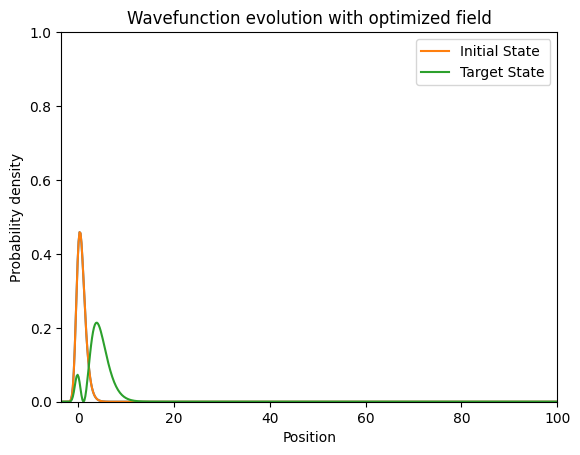

MovieWriter stderr:
convert-im6.q16: unexpected end-of-file `-': No such file or directory @ error/rgb.c/ReadRGBImage/251.
convert-im6.q16: no images defined `wavefunction_evolution.gif' @ error/convert.c/ConvertImageCommand/3234.



CalledProcessError: Command '['convert', '-size', '640x480', '-depth', '8', '-delay', '3.3333333333333335', '-loop', '0', 'rgba:-', '-layers', 'OptimizePlus', 'wavefunction_evolution.gif']' returned non-zero exit status 1.

In [41]:
# Play evolution with optimized field using plt animation
from matplotlib.animation import FuncAnimation

curr_state = psi_0.copy()

# convert from energy basis to position basis for plotting
curr_state_pos = eigstates @ curr_state

fig, ax = plt.subplots()
line, = ax.plot(r_grid, np.abs(curr_state_pos)**2)
ax.set_title("Wavefunction evolution with optimized field")
ax.set_xlabel("Position")
ax.set_ylabel("Probability density")
ax.set_xlim(r_min, 100)
# Plot initial and target states for reference
initial_state_pos = eigstates @ psi_0
target_state_pos = eigstates @ psi_target
ax.plot(r_grid, np.abs(initial_state_pos)**2, label="Initial State")
ax.plot(r_grid, np.abs(target_state_pos)**2, label="Target State")
ax.set_ylim(0, 1)
ax.legend()
def update(frame):
    global curr_state
    curr_state = single_step_evolution(curr_state, controls[opt][frame], exp_H0_fwd, Xi_vals, Xi_vecs, Xi_conjT, delta_t)
    curr_state_pos = eigstates @ curr_state
    line.set_ydata(np.abs(curr_state_pos)**2)
    return line,
ani = FuncAnimation(fig, update, frames=N_T, blit=True, repeat=False)
plt.show()

# save animation as gif (requires imagemagick)
# There are too many frames, so we will save only every 10th frame to reduce the file size
ani.save("wavefunction_evolution.gif", writer='imagemagick', fps=30, savefig_kwargs={'dpi': 80})

for tau in range(N_T):
    curr_state = single_step_evolution(curr_state, controls[opt][tau], exp_H0_fwd, Xi_vals, Xi_vecs, Xi_conjT, delta_t)

In [36]:
np.abs(curr_state[0])

np.float64(0.9862880189155991)

In [42]:
# Overall parameter printout for reproductability
print(f"Optimization parameters:")
print(f"  Total duration T: {T}")
print(f"  Time step δt: {delta_t}")
print(f"  Control update weight λₐ: {lambda_a}")
print(f"  Shape function: Flattop with Blackman ramps (t_on = {t_on}, t_off = {t_off})")

# Field type and parameters
print(f"  Initial guess field: Constant amplitude {initial_field_amplitude}, frequency {initial_frequency:.3f} (resonant with transition between ground and first excited state)")  
print(f"  Optimization iterations: {max_iterations}")
print(f"  Number of energy eigenstates in basis: {base_size}")
print(f"  Position grid: r_min = {r_min:.3f}, r_max = {r_max:.3f}, N_points = {N_points}")
print(f"  Hamiltonian parameters: α = {alpha}, E0 = {E0}")
print(f"  Number of bound states: {np.sum(energies < 0)}")

Optimization parameters:
  Total duration T: 100.0
  Time step δt: 0.05
  Control update weight λₐ: 70
  Shape function: Flattop with Blackman ramps (t_on = 10.0, t_off = 10.0)
  Initial guess field: Constant amplitude 0.5, frequency 0.397 (resonant with transition between ground and first excited state)
  Optimization iterations: 300
  Number of energy eigenstates in basis: 500
  Position grid: r_min = -3.500, r_max = 1000.000, N_points = 5000
  Hamiltonian parameters: α = 1, E0 = -0.5
  Number of bound states: 28


In [12]:
import qutip
import krotov

# H0 is diagonal in the energy eigenbasis — just wrap the diagonal matrix
H0_qobj = qutip.Qobj(np.diag(energies))

# R̂ in the energy eigenbasis: Ξ = V D V⁻¹ — build it once
R_matrix = Xi_vecs @ np.diag(Xi_vals) @ Xi_conjT
H1_qobj = qutip.Qobj(R_matrix)

# Guess field: can be a callable or your precomputed array.
# The callable form lets mesolve evaluate it at arbitrary t.
def guess_control(t, args):
    return float(np.interp(t, time_grid, initial_guess_field))

H = [H0_qobj, [H1_qobj, guess_control]]

In [14]:
psi_0_qobj      = qutip.Qobj(psi_0)
psi_target_qobj = qutip.Qobj(psi_target)

objectives = [
    krotov.Objective(initial_state=psi_0_qobj, target=psi_target_qobj, H=H)
]

def split_op_propagator(H, state, dt, c_ops=None, backwards=False, initialize=False):
    """
    Wraps your split-operator stepper for the krotov package.
    H here is the assembled Hamiltonian at this time step as a Qobj.
    The package calls it as H = H0 + eps*H1, but we bypass that and use
    our pre-factored form for efficiency.
    """
    eps = float(np.real(H[1][1]))   # scalar control value baked in by krotov
    psi = state.full().ravel()       # Qobj -> numpy 1D array

    if not backwards:
        result = single_step_evolution(psi, eps, exp_H0_fwd, Xi_vals, Xi_vecs, Xi_conjT, delta_t)
    else:
        result = single_step_inverse_evolution(psi, eps, exp_H0_bwd, Xi_vals, Xi_vecs, Xi_conjT, delta_t)

    return qutip.Qobj(result)

In [34]:
def S_qutip(t):
    return float(S_l(t, T, t_on, t_off))
krotov_lambda_a = .1
pulse_options = {
    H[1][1]: dict(lambda_a=krotov_lambda_a, update_shape=S_qutip)
}

# cap the total number of iterations and set convergence criteria
opt_result = krotov.optimize_pulses(
    objectives,
    pulse_options=pulse_options,
    tlist=time_grid,
    iter_stop=200,
    propagator=split_op_propagator,
    chi_constructor=krotov.functionals.chis_ss,
    info_hook=krotov.info_hooks.print_table(J_T=krotov.functionals.J_T_ss),
    check_convergence=krotov.convergence.Or(
        krotov.convergence.value_below('1e-3', name='J_T'),
        krotov.convergence.check_monotonic_error,
    ),
    store_all_pulses=True,
)

iter.      J_T    ∫gₐ(t)dt          J       ΔJ_T         ΔJ  secs
0     9.72e-01    0.00e+00   9.72e-01        n/a        n/a     1
1     8.00e-01    4.24e-02   8.43e-01  -1.72e-01  -1.29e-01     8
2     6.80e-01    5.45e-02   7.35e-01  -1.20e-01  -6.56e-02     7
3     6.62e-01    8.81e-03   6.71e-01  -1.79e-02  -9.05e-03     7
4     6.53e-01    4.20e-03   6.57e-01  -8.89e-03  -4.69e-03     8
5     6.29e-01    1.16e-02   6.40e-01  -2.45e-02  -1.30e-02     7
6     6.08e-01    1.03e-02   6.18e-01  -2.09e-02  -1.07e-02     8
7     5.95e-01    6.38e-03   6.02e-01  -1.24e-02  -6.06e-03     7
8     5.86e-01    5.09e-03   5.91e-01  -9.78e-03  -4.69e-03     8
9     5.78e-01    3.98e-03   5.82e-01  -7.81e-03  -3.83e-03     8
10    5.71e-01    3.43e-03   5.74e-01  -6.94e-03  -3.50e-03     8
11    5.64e-01    3.33e-03   5.67e-01  -6.84e-03  -3.51e-03     8
12    5.57e-01    3.46e-03   5.60e-01  -7.18e-03  -3.72e-03     8
13    5.49e-01    3.69e-03   5.53e-01  -7.76e-03  -4.07e-03     8
14    5.41

In [29]:
opt_result

Krotov Optimization Result
--------------------------
- Started at 2026-05-03 20:11:16
- Number of objectives: 1
- Number of iterations: 200
- Reason for termination: Reached 200 iterations
- Ended at 2026-05-03 20:40:15 (0:28:59)

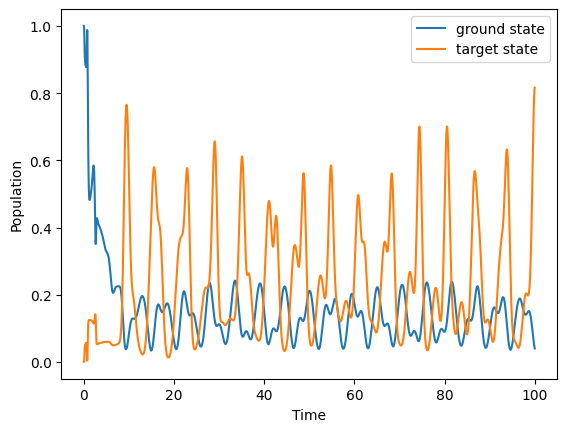

In [25]:
# Plug optimized field into the Hamiltonian and simulate
opt_field = opt_result.optimized_controls[0]  # numpy array on time_grid

H_opt = [H0_qobj, [H1_qobj, opt_field]]

result = qutip.mesolve(
    H_opt,
    psi_0_qobj,
    time_grid,
    e_ops=[psi_0_qobj * psi_0_qobj.dag(), psi_target_qobj * psi_target_qobj.dag()]
)

plt.plot(time_grid, result.expect[0], label='ground state')
plt.plot(time_grid, result.expect[1], label='target state')
plt.xlabel('Time'); plt.ylabel('Population'); plt.legend(); plt.show()

In [35]:
opt_field = opt_result.optimized_controls[0]  # numpy array on time_grid

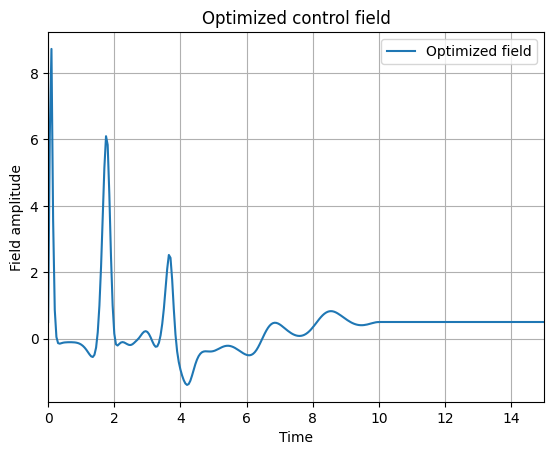

In [37]:
# Plot optimized field
plt.plot(time_grid, opt_field, label='Optimized field')
# plt.plot(time_grid, initial_guess_field, label='Initial guess field')
plt.title("Optimized control field")
plt.xlabel("Time")
plt.ylabel("Field amplitude")
plt.grid()
plt.xlim(0, 15)
plt.legend()
plt.show()